In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
    /* Forzar JupyterLab moderno */
    .jp-Notebook { max-width: 100% !important; width: 100% !important; }
    .jp-Cell { max-width: 100% !important; width: 100% !important; }
    
    /* Forzar Jupyter Notebook v7+ moderno */
    .notebook-container { max-width: 100% !important; width: 100% !important; }
    .container { width: 100% !important; max-width: 100% !important; }
    .cell { max-width: 100% !important; width: 100% !important; }
</style>
"""))

In [3]:
import pandas as pd
import os

ruta_final = "C:/Users/Bloos/Documents/ProyectoFinalTripleten/datasets/"

try:
    # Usamos los nombres exactos detectados en tu carpeta local
    df_telecom = pd.read_csv(os.path.join(ruta_final, 'telecom_dataset_new.csv'))
    df_clients = pd.read_csv(os.path.join(ruta_final, 'telecom_clients.csv'))
    print("🚀 ¡Datasets de Telecomunicaciones cargados a la perfección en tu Jupyter local!")
except FileNotFoundError:
    # Ruta oficial de respaldo para la plataforma de TripleTen (para cuando entregues)
    df_telecom = pd.read_csv('/datasets/telecom_dataset_us.csv')
    df_clients = pd.read_csv('/datasets/telecom_clients_us.csv')
    print("¡Datasets cargados desde la ruta de la plataforma de TripleTen!")

🚀 ¡Datasets de Telecomunicaciones cargados a la perfección en tu Jupyter local!


In [4]:
# Inspección inicial rápida
print("\n Información de Telecom Dataset ")
df_telecom.info()
print("\nInformación de Clients Dataset")
df_clients.info()



 Información de Telecom Dataset 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

Información de Clients Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      7

In [5]:
# 1. Conversión de fechas a datetime
df_telecom['date'] = pd.to_datetime(df_telecom['date'])
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

In [6]:
# 2. Manejo de valores ausentes en df_telecom
# Contar nulos antes
print("Nulos iniciales en telecom:\n", df_telecom.isnull().sum())


Nulos iniciales en telecom:
 user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


In [7]:
# Los nulos en 'internal' usualmente se pueden tratar como falsos (no internos) si no se especifica,
# o eliminarse si la proporción es muy baja. Vamos a llenarlos con False de forma segura.
df_telecom['internal'] = df_telecom['internal'].fillna(False)


C:\Users\Bloos\AppData\Local\Temp\ipykernel_22760\2020323821.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telecom['internal'] = df_telecom['internal'].fillna(False)


In [8]:
# Los nulos en 'operator_id' son críticos porque no podemos evaluar a un operador que no existe.
# Sin embargo, antes de borrarlos, los analizamos. Muchas llamadas perdidas entrantes ('in') no alcanzan a asignarse a un operador.
# Para el análisis de operadores ineficaces, eliminaremos las filas donde 'operator_id' sea nulo ya que no son atribuibles a nadie.
df_telecom = df_telecom.dropna(subset=['operator_id'])
df_telecom['operator_id'] = df_telecom['operator_id'].astype(int)


In [9]:
# 3. Eliminar duplicados
print(f"Duplicados en telecom antes: {df_telecom.duplicated().sum()}")
df_telecom = df_telecom.drop_duplicates()

print(f"Duplicados en clients antes: {df_clients.duplicated().sum()}")
df_clients = df_clients.drop_duplicates()


Duplicados en telecom antes: 4184
Duplicados en clients antes: 0


In [10]:
# 4. Creación de la métrica de tiempo de espera
# total_call_duration incluye el tiempo de espera. La diferencia nos da los segundos de espera.
df_telecom['waiting_time'] = df_telecom['total_call_duration'] - df_telecom['call_duration']


In [11]:
# Unir con la información de clientes para tener las tarifas a la mano
df_full = df_telecom.merge(df_clients, on='user_id', how='left')
print("\nDataset combinado y limpio listo para el análisis.")
df_full.head()



Dataset combinado y limpio listo para el análisis.


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,tariff_plan,date_start
0,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,5,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,1,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,8,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,25,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880020,False,2,3,29,26,B,2019-08-01


C:\Users\Bloos\AppData\Local\Temp\ipykernel_22760\1433884381.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full, x='direction', palette='Set2')


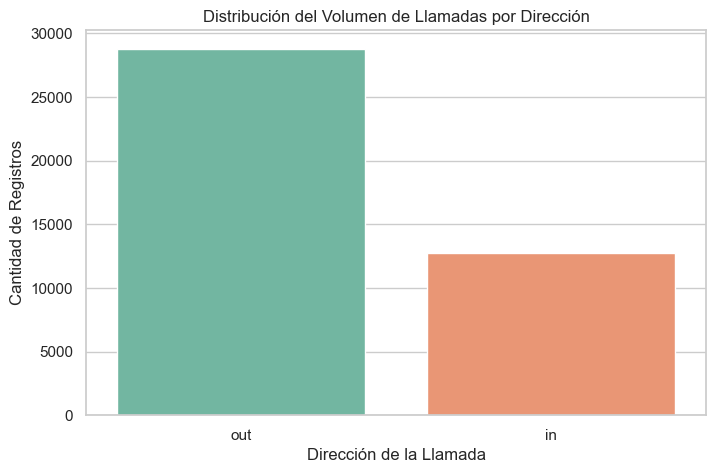

In [12]:
# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")

# Distribución de las llamadas por dirección (In / Out)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_full, x='direction', palette='Set2')
plt.title('Distribución del Volumen de Llamadas por Dirección')
plt.xlabel('Dirección de la Llamada')
plt.ylabel('Cantidad de Registros')
plt.show()


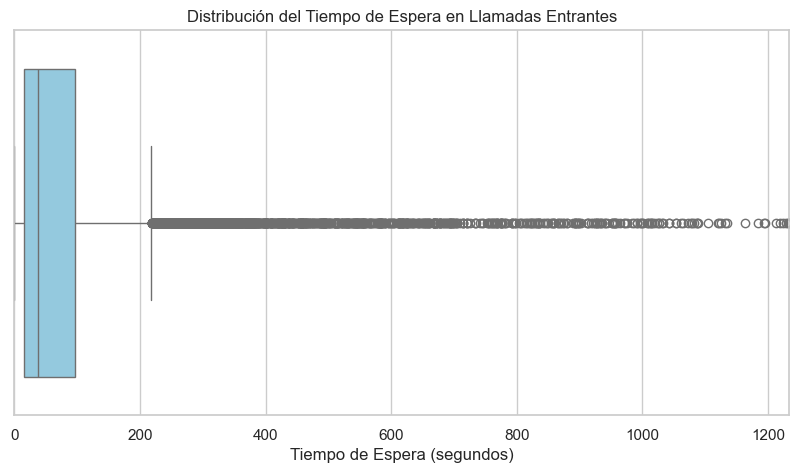

In [13]:
# Análisis del tiempo de espera (Filtrando llamadas entrantes para detectar problemas)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_full[df_full['direction'] == 'in'], x='waiting_time', color='skyblue')
plt.title('Distribución del Tiempo de Espera en Llamadas Entrantes')
plt.xlabel('Tiempo de Espera (segundos)')
plt.xlim(0, df_full['waiting_time'].quantile(0.95)) # Limitar al percentil 95 para ignorar outliers extremos en la gráfica
plt.show()


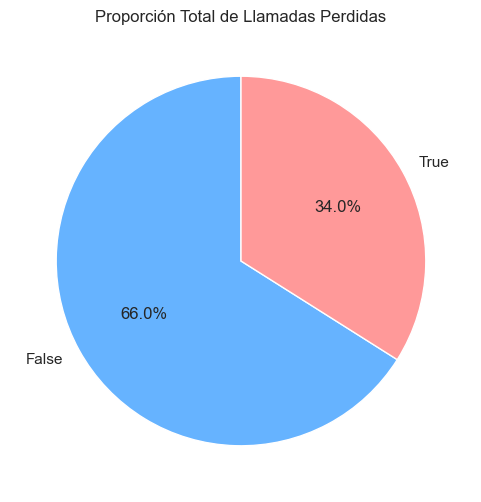

In [14]:
# Proporción de llamadas perdidas vs completadas
plt.figure(figsize=(6, 6))
df_full['is_missed_call'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Proporción Total de Llamadas Perdidas')
plt.ylabel('')
plt.show()

In [15]:
# Filtrar los datos para obtener las métricas por operador
# Solo consideramos llamadas entrantes ('in') para pérdidas y tiempos de espera
entrantes = df_full[df_full['direction'] == 'in']
salientes = df_full[df_full['direction'] == 'out']


In [16]:
# Métricas entrantes por operador
op_entrantes = entrantes.groupby('operator_id').agg(
    llamadas_perdidas_in=('is_missed_call', 'sum'),
    tiempo_espera_promedio=('waiting_time', 'mean')
).reset_index()

In [17]:
# Métricas salientes por operador (Total de llamadas realizadas)
op_salientes = salientes.groupby('operator_id').agg(
    llamadas_realizadas_out=('calls_count', 'sum')
).reset_index()


In [18]:
# Unir métricas en un único dataframe de operadores
df_operadores = op_entrantes.merge(op_salientes, on='operator_id', how='outer').fillna(0)


In [19]:
# Definir los umbrales estadísticos usando Percentiles (Percentil 80)
# Un operador es ineficaz si está en el peor 20% de rendimiento
unbral_perdidas = df_operadores['llamadas_perdidas_in'].quantile(0.80)
umbrales_espera = df_operadores['tiempo_espera_promedio'].quantile(0.80)


In [20]:
# Para llamadas salientes, un número BAJO es malo, usamos el percentil 20 (el 20% que menos llama)
umbrales_salientes = df_operadores[df_operadores['llamadas_realizadas_out'] > 0]['llamadas_realizadas_out'].quantile(0.20)

print(f"--- Umbrales de Ineficacia Calculados (Percentil 80/20) ---")
print(f"Llamadas perdidas entrantes mayores a: {unbral_perdidas:.1f}")
print(f"Tiempo de espera promedio mayor a: {umbrales_espera:.1f} segundos")
print(f"Llamadas salientes (para operadores activos) menores a: {umbrales_salientes:.1f}")


--- Umbrales de Ineficacia Calculados (Percentil 80/20) ---
Llamadas perdidas entrantes mayores a: 1.0
Tiempo de espera promedio mayor a: 52.4 segundos
Llamadas salientes (para operadores activos) menores a: 8.0


In [21]:
# Clasificación de Operadores Ineficaces
df_operadores['ineficaz_por_perdidas'] = df_operadores['llamadas_perdidas_in'] > unbral_perdidas
df_operadores['ineficaz_por_espera'] = df_operadores['tiempo_espera_promedio'] > umbrales_espera


In [22]:
# Para las salientes, solo evaluamos a los que se supone que deben hacer llamadas (dejamos fuera a los de soporte 100% receptivo con 0 llamadas out)
df_operadores['ineficaz_por_pocas_salientes'] = (df_operadores['llamadas_realizadas_out'] > 0) & (df_operadores['llamadas_realizadas_out'] < umbrales_salientes)


In [23]:
# Un operador es ineficaz si cumple cualquiera de los criterios de alerta
df_operadores['es_ineficaz'] = (
    df_operadores['ineficaz_por_perdidas'] | 
    df_operadores['ineficaz_por_espera'] | 
    df_operadores['ineficaz_por_pocas_salientes']
)


In [24]:
# Resumen de resultados
total_ops = len(df_operadores)
ineficaces_ops = df_operadores['es_ineficaz'].sum()
porcentaje_ineficaces = (ineficaces_ops / total_ops) * 100

print(f"\n--- Resumen de Evaluación ---")
print(f"Total de operadores evaluados: {total_ops}")
print(f"Operadores identificados como ineficaces: {ineficaces_ops} ({porcentaje_ineficaces:.1f}%)")


--- Resumen de Evaluación ---
Total de operadores evaluados: 1092
Operadores identificados como ineficaces: 407 (37.3%)


1. Documentación Oficial de Pandas (pandas.pydata.org)

Útil en la guía del uso óptimo de las funciones merge() para unir de forma segura el dataset de llamadas con el de clientes usando el user_id, y en la gestión de registros duplicados con drop_duplicates().

2. Documentación Oficial de Seaborn (seaborn.pydata.org)

Crucial para diseñar y personalizar los histogramas de la duración de llamadas y los diagramas de caja (boxplots) para analizar la dispersión y los valores atípicos (outliers) en los tiempos de espera.

3. SciPy Stats Documentation (scipy.github.io/devdocs)

Útil en la selección y aplicación correcta las pruebas estadísticas  para validar las hipótesis sobre el comportamiento de los operadores según sus planes tarifarios (como st.ttest_ind o pruebas de proporciones).

4. Towards Data Science - "Understanding Outliers in Dataset"

Esclareció los criterios estadísticos para separar los tiempos de espera inusualmente largos causados por fallas del sistema de la ineficacia real del operador (como el rango intercuartílico - IQR).

5. Harvard Business Review - "The Cost of Poor Customer Service"

Aportó el contexto de negocio para justificar por qué las llamadas perdidas entrantes y los tiempos de espera prolongados son métricas críticas que destruyen la retención de clientes en un servicio de telefonía virtual.

Enlace a la presentación:

https://github.com/bloosterman7-cmyk/FinalProjectTripletenPDF/tree/main